<a href="https://colab.research.google.com/github/ishaijaz11112222-del/Data-Science-Bootcamp/blob/main/session5_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("for datascience student data(1).csv")
df.head()

,sex,age,studytime,failures,internet,absences,G1,G3
0,F,18.0,2.0,0.0,no,6.0,5.0,6
1,F,17.0,2.0,0.0,yes,4.0,5.0,6
2,F,15.0,2.0,3.0,yes,10.0,7.0,10
3,F,15.0,3.0,0.0,yes,2.0,15.0,15
4,F,16.0,2.0,0.0,no,NaN,6.0,10


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sex        395 non-null    object 
 1   age        390 non-null    float64
 2   studytime  390 non-null    float64
 3   failures   392 non-null    float64
 4   internet   392 non-null    object 
 5   absences   388 non-null    float64
 6   G1         390 non-null    float64
 7   G3         395 non-null    int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 24.8+ KB


In [4]:
df.select_dtypes(include=np.number).columns

Index(['age', 'studytime', 'failures', 'absences', 'G1', 'G3'], dtype='object')

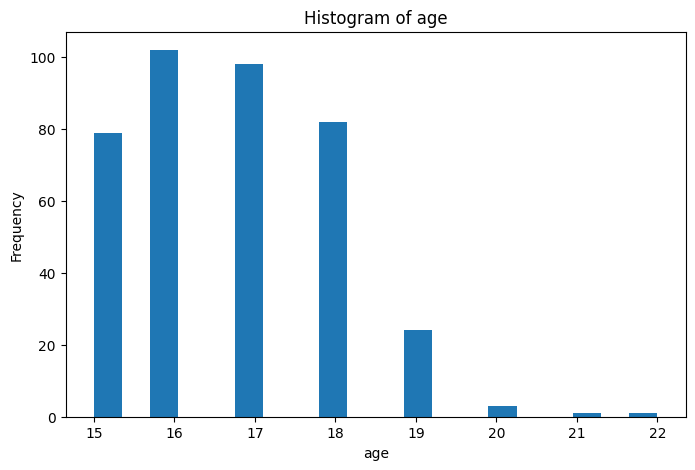

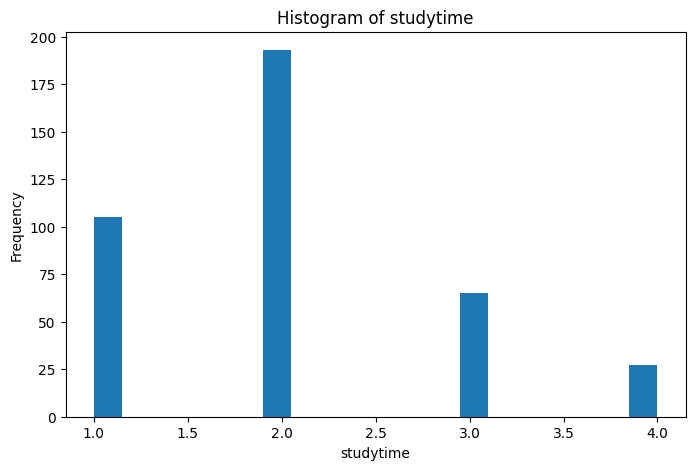

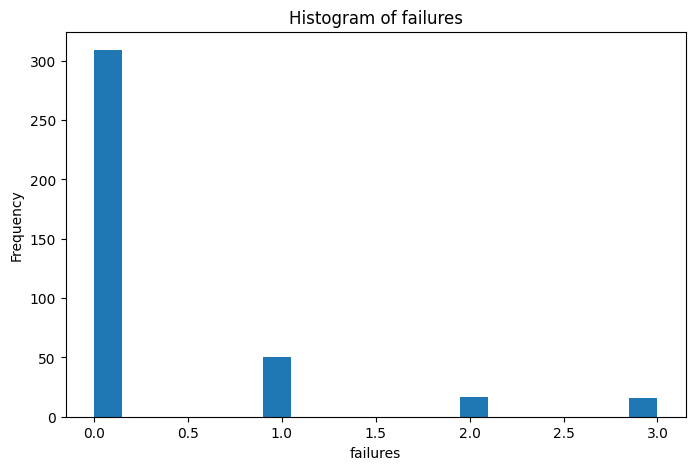

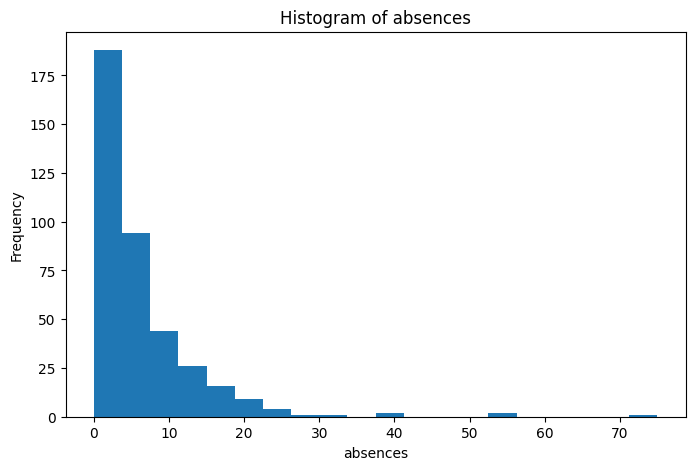

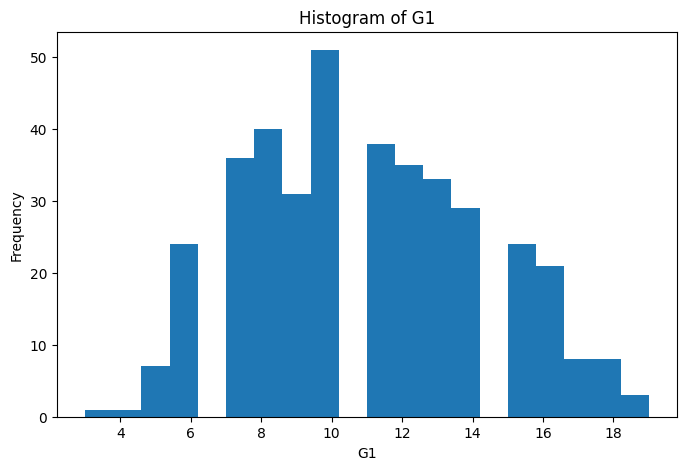

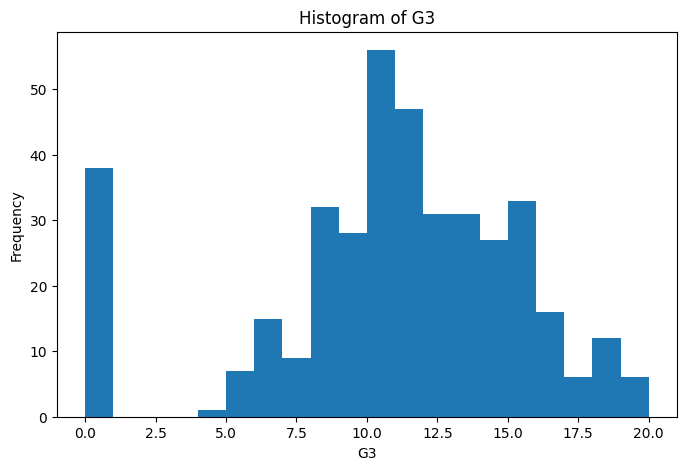

In [5]:
numeric_columns= df.select_dtypes(include=np.number).columns
for column in numeric_columns:
    plt.figure(figsize=(8, 5))
    plt.hist(df[column].dropna(), bins=20)
    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

In [7]:
df.columns

Index(['sex', 'age', 'studytime', 'failures', 'internet', 'absences', 'G1',
       'G3'],
      dtype='object')

# task2: Grouped Box Plots

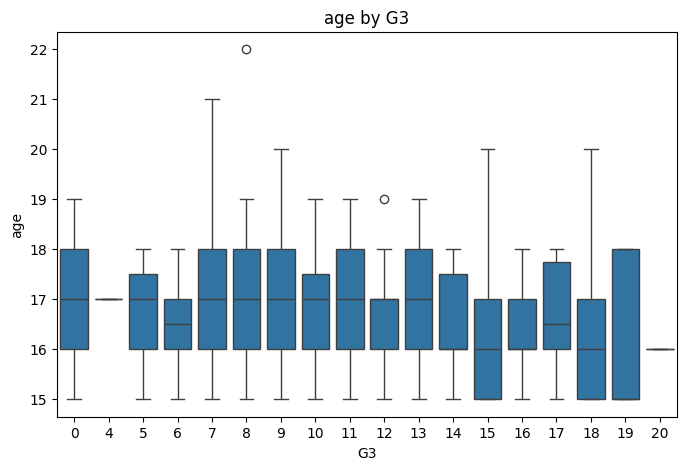

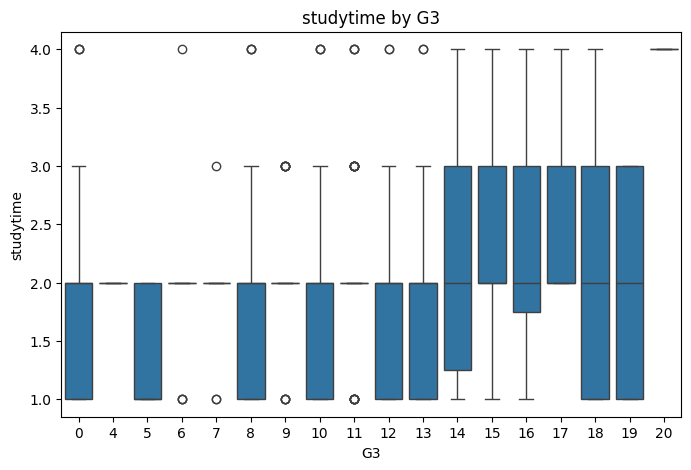

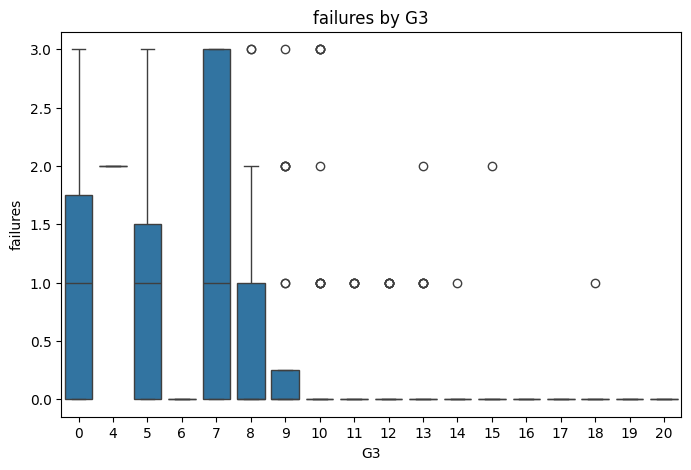

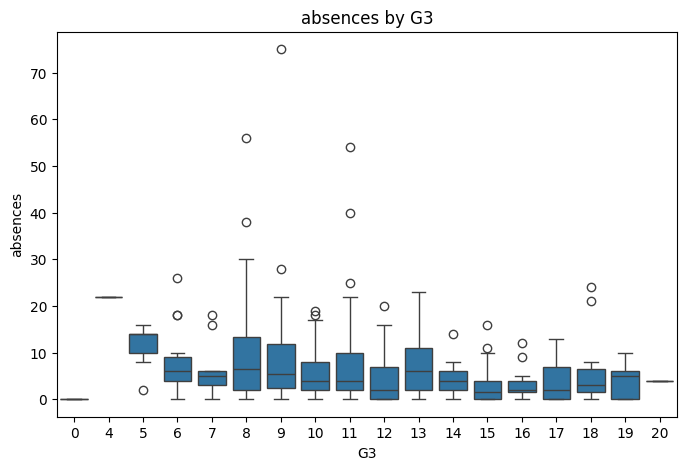

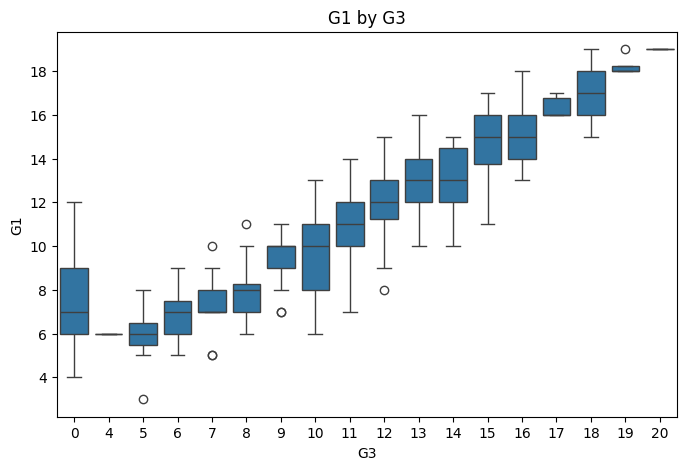

In [6]:
target = "G3"

features = ["age", "studytime", "failures", "absences", "G1"]

for column in features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[target], y=df[column])
    plt.title(f"{column} by G3")
    plt.xlabel("G3")
    plt.ylabel(column)
    plt.show()

#Task 3 — Correlation Heatmap

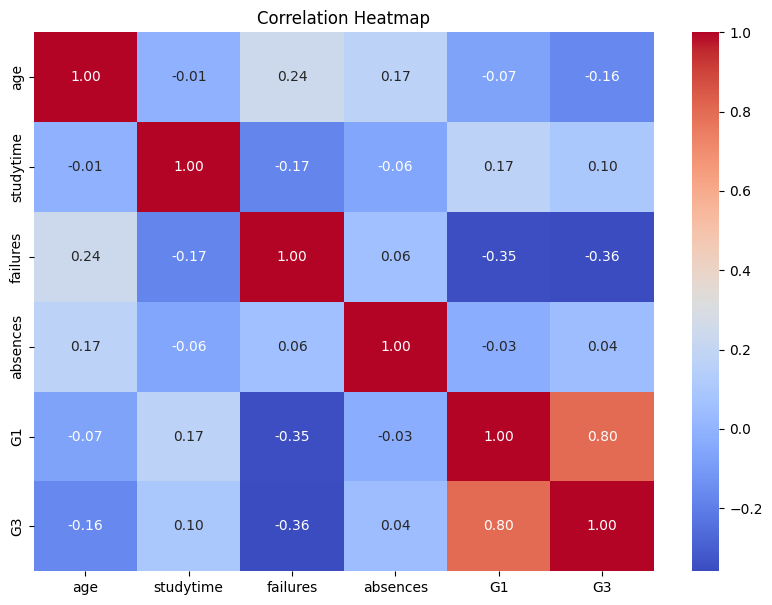

In [7]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [8]:
correlation_with_target = numeric_df.corr()["G3"].drop("G3")

top_3_features = correlation_with_target.abs().sort_values(ascending=False).head(3)

print("Top 3 Features:")
print(top_3_features)

Top 3 Features:
G1          0.802534
failures    0.359158
age         0.164674
Name: G3, dtype: float64


# Task 4: Detect outliers from IQR Rule

In [9]:
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"{column}: {len(outliers)} outliers")

age: 1 outliers
studytime: 27 outliers
failures: 83 outliers
absences: 15 outliers
G1: 0 outliers
G3: 0 outliers


In [10]:
 # Outlier detection evidence
 numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"{column}: {len(outliers)} outliers")
outlier_summary = []

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    count = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()

    outlier_summary.append([column, Q1, Q3, IQR, lower_bound, upper_bound, count])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["Feature", "Q1", "Q3", "IQR", "Lower Bound", "Upper Bound", "Outliers"]
)

outlier_df

age: 1 outliers
studytime: 27 outliers
failures: 83 outliers
absences: 15 outliers
G1: 0 outliers
G3: 0 outliers


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers
0,age,16.0,18.0,2.0,13.0,21.0,1
1,studytime,1.0,2.0,1.0,-0.5,3.5,27
2,failures,0.0,0.0,0.0,0.0,0.0,83
3,absences,0.0,8.0,8.0,-12.0,20.0,15
4,G1,8.0,13.0,5.0,0.5,20.5,0
5,G3,8.0,14.0,6.0,-1.0,23.0,0


### Outlier Treatment Decisions

- Study Time: Keep
  Explanation: The outliers could be students who study for an unusually long period of time. These values can have significance and they must not be deleted simply because they are determined to be errors.

- Failures: Keep
  Justification: Some students can get higher failure rates and it can be helpful in getting information on academic performance.

- Absences: Keep
  Context: High absences can be real and might provide an explanation for the differences in students' final grades.

- G1: Keep
  Support: There were no outliers found by the IQR rule.

- G3: Keep
  Note: No outliers were identified with the IQR rule.
This is the overview for my assignment part 4..........

In [11]:
correlation_with_target = df.select_dtypes(include=np.number).corr()["G3"].drop("G3")

print("Correlation with G3:")
print(correlation_with_target.sort_values(ascending=False))

print("\nTop 3 Features:")
print(correlation_with_target.abs().sort_values(ascending=False).head(3))

Correlation with G3:
G1           0.802534
studytime    0.098344
absences     0.041806
age         -0.164674
failures    -0.359158
Name: G3, dtype: float64

Top 3 Features:
G1          0.802534
failures    0.359158
age         0.164674
Name: G3, dtype: float64


## Task 5: Written Insights

In [14]:
print("Top 3 Features:")
print(correlation_with_target.abs().sort_values(ascending=False).head(3))

print("\nAverage G3:")
print(df["G3"].mean())

print("\nAverage Absences:")
print(df["absences"].mean())

print("\nAverage Study Time:")
print(df["studytime"].mean())

print("\nAverage Failures:")
print(df["failures"].mean())

Top 3 Features:
G1          0.802534
failures    0.359158
age         0.164674
Name: G3, dtype: float64

Average G3:
10.415189873417722

Average Absences:
5.729381443298969

Average Study Time:
2.0358974358974358

Average Failures:
0.336734693877551


## Task 5: Written Insights

The G1 score has the highest positive correlation with the final grade (G3), suggesting that the higher the G1 score, the higher the final score.

The results indicate a negative correlation between failures and the final grade (G3), meaning that students who had more failures in the past tended to obtain lower final grades.

Absence have a weaker relationship with G3 than with G1 and failures and absence by itself is not as strong a predictor of final grade.

From the distribution plot, Study Time, it can be seen that most students are in the common study-time categories, and a few students are in the uncommon study-time categories.

The IQR analysis found some outliers in the following variables: Study Time, Failures, Absences. These values were preserved, as they might be representative of student behaviour, and could include valuable information and not be data entry mistakes.